# 1 - Read the WAV file



In [1]:
import struct
import numpy as np
import matplotlib.pyplot as plt

def load_audio(file_path):
    sample_rate = 0
    with open(file_path,'rb') as audio_file:
        header = audio_file.read(44)
        print(f"The header is {header}")
        if header[:4] != b'RIFF' or header[8:12] != b'WAVE' or header[12:16] != b'fmt ':
            raise ValueError("Invalid WAV file")
        header_chunk_id = struct.unpack('4s', header[0:4])[0]
        header_chunk_size = struct.unpack('<I', header[4:8])[0]
        header_chunk_format = struct.unpack('4s', header[8:12])[0]
        format_chunk_id = struct.unpack('4s', header[12:16])[0]
        format_chunk_size = struct.unpack('<I', header[16:20])[0]
        format_code = struct.unpack('<H', header[20:22])[0]
        channels = struct.unpack('<H', header[22:24])[0]
        sample_rate = struct.unpack('<I', header[24:28])[0]
        byte_rate = struct.unpack('<I', header[28:32])[0]
        block_align = struct.unpack('<H', header[32:34])[0]
        sample_width = struct.unpack('<H', header[34:36])[0]
        data_chunk_id = struct.unpack('4s', header[36:40])[0]
        data_chunk_size = struct.unpack('<I', header[40:44])[0]
        audio_file.seek(44)
        data = audio_file.read(data_chunk_size)
    data_array = np.frombuffer(data, dtype=np.int32)
    data_array = data_array.astype(np.float32)
    return sample_rate,data_array

## Audi plot

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


The header is b'RIFF\xe4\xa9\x04\x00WAVEfmt \x10\x00\x00\x00\x01\x00\x01\x00@\x9c\x00\x00\x808\x01\x00\x02\x00\x10\x00data\xc0\xa9\x04\x00'


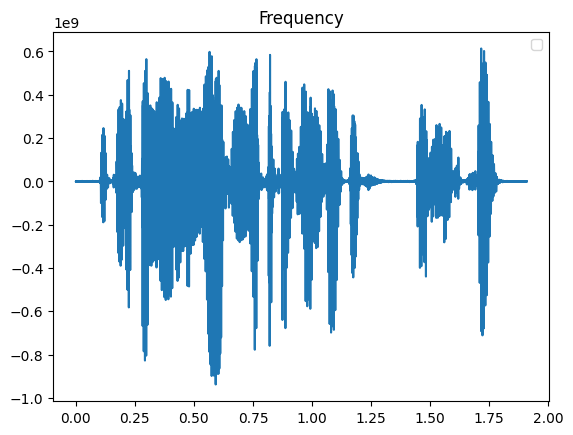

In [2]:
def plot_audio(file_path):
    sample_rate,data_array = load_audio(file_path)
    x_axis = np.arange(0,len(data_array)) / sample_rate
    plt.plot(x_axis,data_array)
    plt.title("Frequency")
    plt.legend()
plot_audio("output-1.wav")

## Amplify

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


The header is b'RIFF\xe4\xa9\x04\x00WAVEfmt \x10\x00\x00\x00\x01\x00\x01\x00@\x9c\x00\x00\x808\x01\x00\x02\x00\x10\x00data\xc0\xa9\x04\x00'
131072.0
40000


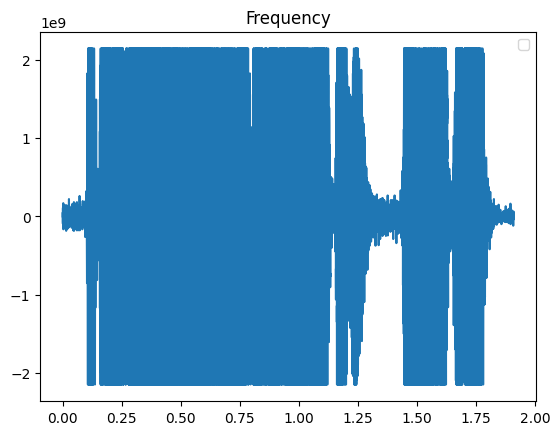

In [34]:
import wave
def amplify(file_path):
    sample_rate,data_array = load_audio(file_path)
    amplified_data = data_array * 100
    print(data_array[1])
    #Anti-distortion
    amplified_data = np.clip(amplified_data, -2147483648, 2147483647)
    amplified_data = amplified_data.astype(np.int32)
    
    x_axis = np.arange(0,len(data_array)) / sample_rate
    plt.plot(x_axis,amplified_data)
    plt.title("Frequency")
    plt.legend()
    output_file = "amplified_audio.wav"
    
    with wave.open(output_file, 'wb') as out_wave_file:
        out_wave_file.setnchannels(1)
        out_wave_file.setsampwidth(4)
        print(sample_rate)
        out_wave_file.setframerate(sample_rate * 0.5) # I am using 32-bits so I have to multiply it by 1/2 to make it slower 
        
        for sample in amplified_data:
            out_wave_file.writeframes(struct.pack('<i', sample)) 
            
amplify("output-1.wav")